# Notebookuse

Dieses Notebook wurde erstellt, um während der Datenbeschaffung einen Überblick über die Verteilung der Aufnahmen zu haben. So konnten gezielt bestimmte Klassen häufiger aufgenommen werden als andere je nahc Bedarf.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:

base_path = "../Daten"
sensors = ["Accelerometer", "Gyroscope", "Orientation"]

def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

def find_measurement_folders(base):
    """Liefert (folder_path, author).
    Author = Name des User-Unterordners (Daten/<user>/<measurement>).
    Wenn ein Mess-Ordner direkt unter Daten/ liegt (kein User zugeordnet), ist author = 'Unbekannt'.
    """
    out = []
    for entry in sorted(os.listdir(base)):
        entry_path = os.path.join(base, entry)
        if not os.path.isdir(entry_path):
            continue
        if os.path.exists(os.path.join(entry_path, "Tags.csv")):
            out.append((entry_path, "Unbekannt"))
        else:
            for sub in sorted(os.listdir(entry_path)):
                sub_path = os.path.join(entry_path, sub)
                if os.path.isdir(sub_path) and os.path.exists(os.path.join(sub_path, "Tags.csv")):
                    out.append((sub_path, entry))
    return out

raw_dfs = {sensor: [] for sensor in sensors}
measurement_id = 0

for folder_path, author in find_measurement_folders(base_path):
    try:
        tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))

        for sensor in sensors:
            data = pd.read_csv(os.path.join(folder_path, f"{sensor}.csv"))
            data["Sensor"] = sensor
            data["time"] = pd.to_datetime(data["time"])
            data["Tag"] = tag["tag"].iloc[0]
            data["ID"] = measurement_id
            data["Author"] = author
            raw_dfs[sensor].append(data)

    except Exception as e:
        print(f"Fehler in Ordner {folder_path}: {e}")

    measurement_id += 1  # einmal pro Ordner, nicht pro Sensor

# Zusammenfuehren und trimmen
dfs = {}
for sensor in sensors:
    raw = pd.concat(raw_dfs[sensor], ignore_index=True)
    raw["ID_backup"] = raw["ID"]
    dfs[sensor] = (
        raw
        .groupby("ID_backup", group_keys=False)
        .apply(trim_measurement)
        .reset_index(drop=True)
    )

# Zugriff auf die einzelnen DataFrames
acc_df  = dfs["Accelerometer"]
gyr_df  = dfs["Gyroscope"]
ori_df  = dfs["Orientation"]

C:\Users\jessi\AppData\Local\Temp\ipykernel_31164\2466516837.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_measurement)
C:\Users\jessi\AppData\Local\Temp\ipykernel_31164\2466516837.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_measurement)
C:\Users\jessi\AppData\Local\Temp\ipykernel_31164\2466516837.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. Th

Da es nur um die Anzahl Aufnahmen geht wurden nur die Accelerometer Daten verwendet um dies zu überprüfen. 

In [25]:
final_df = acc_df  # bereits getrimmt

final_df["ID_backup"] = final_df["ID"]  # falls du ID_backup noch brauchst

df = final_df.reset_index(drop=True)  # kein groupby/apply/trim mehr

In [26]:
print("Grösse des Datensatzes:", df.shape)

Grösse des Datensatzes: (3077151, 10)


# Verteilung der Klassen

Der erste Plot zeigt die Verteilung nach Anzahl Zeilen im Datensatz. Der zweite Plot dagegen zeigt die absolute Anzahl Aufnahmen pro Klasse. 

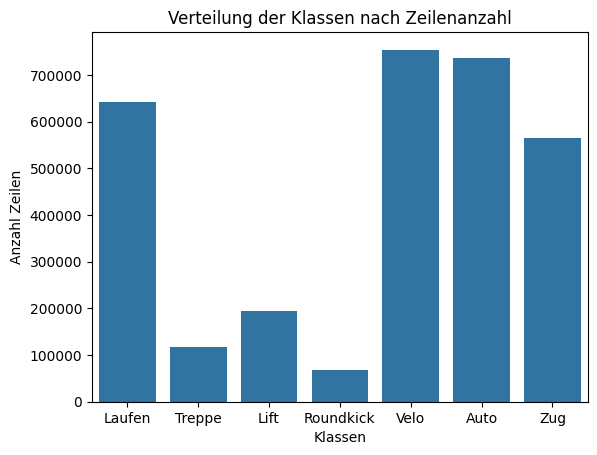

In [27]:
sns.countplot(df, x="Tag")
plt.title("Verteilung der Klassen nach Zeilenanzahl")
plt.xlabel("Klassen")
plt.ylabel("Anzahl Zeilen")
plt.show()

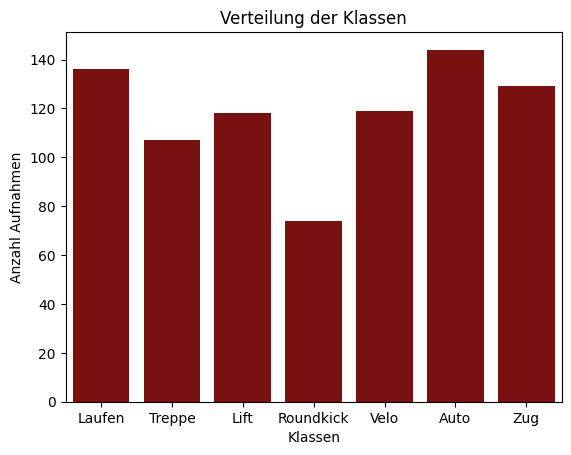

In [28]:
# Eine Zeile pro ID behalten, dann Tags zählen
df_unique = df.drop_duplicates(subset="ID")[["ID", "Tag"]]

sns.countplot(df_unique, x="Tag", color="darkred")
plt.title("Verteilung der Klassen")
plt.xlabel("Klassen")
plt.ylabel("Anzahl Aufnahmen")
plt.show()